In [26]:
using Pkg
Pkg.develop(path="../apuu")

using Revise
using apuu.RobotEnv2D: POMDPscenario, GenerateRangedObservationFromBeacons, GenerateSingleRangedBeaconObservation, beacon_grid, GenerateObservationFromBeacons
using apuu.GaussianFilter: PropagateBelief, PosteriorBeliefRangedBeacons, PosteriorBeliefBeacons
using apuu.RobotEnv2D: POMDPscenario, SampleMotionModel
# using apuu.ParticleFilter: ParticleBelief, PropagateParticleBelief, PosteriorParticleBelief, ResampleParticles
using apuu.Paths: HW3_PLOTS

using Revise
using Distributions
using Random
using LinearAlgebra
using Plots
using StatsPlots
using Parameters
using StatsBase

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


# Part 1 Parameters:

In [2]:
# definition of the random number generator with seed
ID = 318803129
rng = MersenneTwister(ID)

# parameters
μ0 = [0.0,0.0]
Σ0 = I(2)
F = I(2)
Σw = 0.1^2 * I(2)
Σv = 0.1^2*I(2) # place holder, measurement noise is dynamically changing in this setting
d = 1.0
rmin = 0.1
beacons = beacon_grid()

𝒫 = POMDPscenario(F=F, Σw=Σw, Σv=Σv, rng=rng, beacons=beacons, d=d, rmin=rmin)

POMDPscenario
  F: Array{Float64}((2, 2)) [1.0 0.0; 0.0 1.0]
  Σw: Array{Float64}((2, 2)) [0.010000000000000002 0.0; 0.0 0.010000000000000002]
  Σv: Array{Float64}((2, 2)) [0.010000000000000002 0.0; 0.0 0.010000000000000002]
  rng: MersenneTwister
  beacons: Array{Float64}((9, 2)) [0.0 0.0; 4.5 0.0; … ; 4.5 9.0; 9.0 9.0]
  d: Float64 1.0
  rmin: Float64 0.1


# (a) 

The observation model is given by:

## Case 1: there's a beacon within range d

Assume the index of the nearby beacon is $i$

$z^{rel}_{k+1} = (x_{k+1} - X^b_i) + v_{k+1}$

where

$r = ||x_{k+1} - X^b_i||$

$v_{k+1} \sim N(0, 0.1^2 \cdot \max(r, r_{min})^2 \cdot I_2)$

## Case 2: no beacon within range d

Then no observation is made.


# (b) Probabilistic inference for gaussian distributions

Given: 

$b(X_k) = N(\mu_k, \Sigma_k)$, $a_k$, $z_{k+1}^{\text{rel}}$

We compute the new belief using probabilistic inference, which in the gaussian case is also known as the Kalman filter. 

The predicted mean and covariance are given by:

$\bar \mu = \mu_k + a_k$

$\bar \Sigma = \Sigma_k + \Sigma_w$

We consider the observation error at the predicted mean in order to obtain closed form equations for the updated mean and covariance:

$r = ||\bar \mu - x_\text{beacon}||$


$\Sigma_{v} = 0.1^2 \cdot (\max(r, r_{min}))^2 \cdot I_2$

$z_{k+1} = z_{k+1}^{\text{rel}} + x_\text{beacon}$

The updated mean and covariance are given by:

$K = \bar \Sigma (\bar \Sigma + \Sigma_v)^{-1}$

$\mu_{k+1} = (I-K) \bar \mu + K z_{k+1}$

$\Sigma_{k+1} = (I-K) \bar \Sigma$


If the observation is null (i.e., no beacon detected), then the belief remains the predicted belief:

$\mu_{k+1} = \bar \mu$

$\Sigma_{k+1} = \bar \Sigma$




# (c)

In [3]:
b = MvNormal(μ0, Matrix(Σ0)) # [0,0], I(2)
a = [13., 13.]

# expected mean is [13,13]
# expected covariance is F*Σ0*F' + Σw = I(2) + 0.01*I(2) = 1.01*I(2)
PropagateBelief(𝒫, b, a) 

FullNormal(
dim: 2
μ: [13.0, 13.0]
Σ: [1.01 0.0; 0.0 1.01]
)


# (d)

In [4]:
GenerateSingleRangedBeaconObservation(𝒫, [0.0, 0.0], [0.0, 0.0])

2-element Vector{Float64}:
 0.004640506153350725
 0.0005069125372255805

In [5]:
X = [0.4, 0.4]
GenerateRangedObservationFromBeacons(𝒫, X)

([0.3983909778417857, 0.25901277473948603], 1)

In [6]:
GenerateRangedObservationFromBeacons(𝒫, [4.1, 4.1])

([-0.4709935915662477, -0.4805447148976204], 5)

# (e)

In [7]:
b = MvNormal(μ0, Matrix(Σ0)) # [0,0], I(2)
a = [4.6, 4.6]
z = (obs=[0.1, 0.1], beacon_index=5)

# mu should be 4.6, 4.6 because beacon and action agree
PosteriorBeliefRangedBeacons(𝒫, b, a, z) 

FullNormal(
dim: 2
μ: [4.6, 4.6]
Σ: [0.0001999604038803393 0.0; 0.0 0.0001999604038803393]
)


In [8]:
# low process noise should bias estimate towards prediction:
𝒫 = POMDPscenario(F=F, Σw=1e-10*I(2), Σv=Σv, rng=rng, beacons=beacons, d=d, rmin=rmin)


b = MvNormal(μ0, 1e-10 * Matrix(Σ0)) # [0,0], I(2)
a = [4.4, 4.4]
z = (obs=[0.1, 0.1], beacon_index=5)

println("Beacon position:")
println(𝒫.beacons[5,:])
println("")

# mu should be close to 4.4, 4.4 because beacon covariance is lower
PosteriorBeliefRangedBeacons(𝒫, b, a, z) 

Beacon position:
[4.5, 4.5]



FullNormal(
dim: 2
μ: [4.4000001999998, 4.4000001999998]
Σ: [1.999998000002e-10 0.0; 0.0 1.999998000002e-10]
)


In [9]:
# high process noise should bias estimate towards prediction:
𝒫 = POMDPscenario(F=F, Σw=10*I(2), Σv=Σv, rng=rng, beacons=beacons, d=d, rmin=rmin)


b = MvNormal(μ0, 10 * Matrix(Σ0)) # [0,0], I(2)
a = [4.4, 4.4]
z = (obs=[0.1, 0.1], beacon_index=5)

println("Beacon position:")
println(𝒫.beacons[5,:])
println("")

# mu should be close to 4.6, 4.6
PosteriorBeliefRangedBeacons(𝒫, b, a, z) 

Beacon position:
[4.5, 4.5]



FullNormal(
dim: 2
μ: [4.599998000019999, 4.599998000019999]
Σ: [0.00019999800001890833 0.0; 0.0 0.00019999800001890833]
)


# (f)

In [10]:
# definition of the random number generator with seed
ID = 318803129
rng = MersenneTwister(ID)

# parameters
μ0 = [0.0,0.0]
Σ0 = I(2)
F = I(2)
Σw = 0.1^2 * I(2)
Σv = I(2) # place holder, measurement noise is dynamically changing in this setting
d = 1.0
rmin = 0.1
beacons = beacon_grid() # 9 evenly spread beacons over a 9 x 9 grid, left corner at 0,0

X0 = [-0.5, -0.2]
T = 10
ai = [1., 1.]

b = MvNormal(μ0, Matrix(Σ0)) # initial belief
𝒫 = POMDPscenario(F=F, Σw=Σw, Σv=Σv, rng=rng, beacons=beacons, d=d, rmin=rmin)

POMDPscenario
  F: Array{Float64}((2, 2)) [1.0 0.0; 0.0 1.0]
  Σw: Array{Float64}((2, 2)) [0.010000000000000002 0.0; 0.0 0.010000000000000002]
  Σv: Array{Float64}((2, 2)) [1.0 0.0; 0.0 1.0]
  rng: MersenneTwister
  beacons: Array{Float64}((9, 2)) [0.0 0.0; 4.5 0.0; … ; 4.5 9.0; 9.0 9.0]
  d: Float64 1.0
  rmin: Float64 0.1


In [11]:
𝒫.beacons

9×2 Matrix{Float64}:
 0.0  0.0
 4.5  0.0
 9.0  0.0
 0.0  4.5
 4.5  4.5
 9.0  4.5
 0.0  9.0
 4.5  9.0
 9.0  9.0

# (f - 1, 2) 

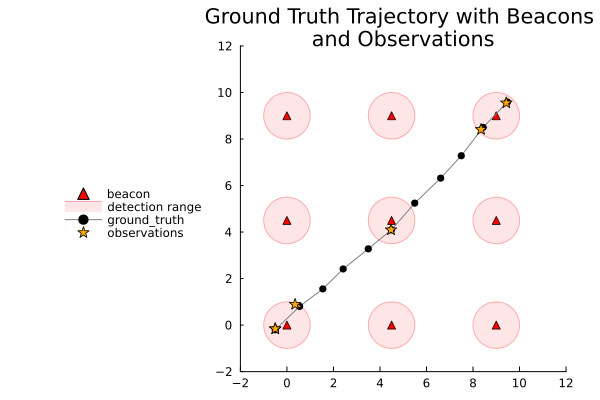

UndefVarError: UndefVarError: `HW2_PLOTS` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [12]:
beacons = 𝒫.beacons


# generate motion trajectory
τ = [X0] # trajectory
for i in 1:T
    push!(τ, SampleMotionModel(𝒫, ai, τ[end]))
end
τ = hcat(τ...)'  # convert to matrix form


# generate relative observations trajectory
τ_obs_beacons = []
beacon_indexes = []
for i in 1:T+1
    obs = GenerateRangedObservationFromBeacons(𝒫, τ[i,:])
    if obs != nothing
        push!(τ_obs_beacons, obs[1])
        push!(beacon_indexes, obs[2])
    else
        push!(τ_obs_beacons, [NaN, NaN])  # or some other placeholder for no observation
        push!(beacon_indexes, NaN)
    end
end
τ_obs_beacons = hcat(τ_obs_beacons...)'  # convert to matrix form


# -------------- PLOTTING --------------


# plot ground truth trajectory with beacons and observations:
# Plot beacons first (in the back)
pl_beacons = scatter(beacons[:,1], beacons[:,2], 
                     label="beacon", 
                     markershape=:utriangle, 
                     markersize=4,
                     markercolor=:red,
                     title="Ground Truth Trajectory with Beacons \nand Observations",
                     grid=false,
                     aspect_ratio=:equal,
                     xlims=(-2, 12),
                     ylims=(-2, 12),
                     legend=:outerleft,
                     background_color_legend=nothing,
                     foreground_color_legend=nothing)

# Add detection radius circles around each beacon
θ = range(0, 2π, length=100)
for i in 1:size(beacons, 1)
    x_circle = beacons[i, 1] .+ 𝒫.d * cos.(θ)
    y_circle = beacons[i, 2] .+ 𝒫.d * sin.(θ)
    plot!(pl_beacons, x_circle, y_circle, 
          fillrange=beacons[i, 2],
          fillalpha=0.1, 
          fillcolor=:red,
          linecolor=:red,
          linealpha=0.3,
          linewidth=1,
          label=i==1 ? "detection range" : "")
end

# Plot ground truth trajectory on top
plot!(pl_beacons, τ[:,1], τ[:,2], 
      label="ground_truth", 
      markershape=:circle, 
      markercolor=:black,
      linecolor=:gray, 
      linestyle=:solid)


# Plot observations (convert relative to absolute positions)
# First pass: plot all connections and observations without label
for i in 1:size(τ_obs_beacons, 1)
    if !isnan(τ_obs_beacons[i, 1])
        
        # shift relative observation to absolute
        obs_end = τ_obs_beacons[i, :] + 𝒫.beacons[beacon_indexes[i], :]
        
        # Draw line from robot to sensed beacon location
        plot!(pl_beacons, 
              [τ[i,1], obs_end[1]], 
              [τ[i,2], obs_end[2]],
              color=:orange, 
              label="", 
              linewidth=1.5,
              linestyle=:dash)
              
        # Plot observation marker
        scatter!(pl_beacons, [obs_end[1]], [obs_end[2]], 
                 markercolor=:orange, 
                 markershape=:star5,
                 markersize=6,
                 label="")
    end
end

# legend
obs_indices = findall(x -> !isnan(x), τ_obs_beacons[:, 1])
if !isempty(obs_indices)
    i = obs_indices[1]
    obs_end = τ_obs_beacons[i, :] + 𝒫.beacons[beacon_indexes[i], :]
    scatter!(pl_beacons, [obs_end[1]], [obs_end[2]], 
             markercolor=:orange, 
             markershape=:star5,
             markersize=6,
             label="observations")
end

display(pl_beacons)
savefig(pl_beacons, joinpath(HW2_PLOTS, "3f12_trajectory_beacons_observations_$ID.png"))

# (f-3) belief propogation (no obserations)

In [13]:
b

FullNormal(
dim: 2
μ: [0.0, 0.0]
Σ: [1.0 0.0; 0.0 1.0]
)


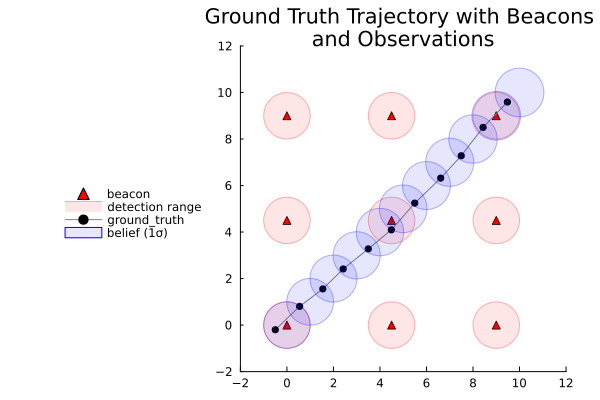

In [14]:
beliefs = Vector{FullNormal}(undef, T+1)
beliefs[1] = b
for t in 1:T
    beliefs[t+1] = PropagateBelief(𝒫, beliefs[t], ai)
end

# -------------- PLOTTING --------------


# plot ground truth trajectory with beacons and observations:
# Plot beacons first (in the back)
pl_beacons = scatter(beacons[:,1], beacons[:,2], 
                     label="beacon", 
                     markershape=:utriangle, 
                     markersize=4,
                     markercolor=:red,
                     title="Ground Truth Trajectory with Beacons \nand Observations",
                     grid=false,
                     aspect_ratio=:equal,
                     xlims=(-2, 12),
                     ylims=(-2, 12),
                     legend=:outerleft,
                     background_color_legend=nothing,
                     foreground_color_legend=nothing)

# Add detection radius circles around each beacon
θ = range(0, 2π, length=100)
for i in 1:size(beacons, 1)
    x_circle = beacons[i, 1] .+ 𝒫.d * cos.(θ)
    y_circle = beacons[i, 2] .+ 𝒫.d * sin.(θ)
    plot!(pl_beacons, x_circle, y_circle, 
          fillrange=beacons[i, 2],
          fillalpha=0.1, 
          fillcolor=:red,
          linecolor=:red,
          linealpha=0.3,
          linewidth=1,
          label=i==1 ? "detection range" : "")
end

# Plot ground truth trajectory on top
plot!(pl_beacons, τ[:,1], τ[:,2], 
      label="ground_truth", 
      markershape=:circle, 
      markercolor=:black,
      linecolor=:gray, 
      linestyle=:solid)


# plot beliefs:
for t in 1:T+1
    bt = beliefs[t]
    covellipse!(pl_beacons, mean(bt), cov(bt), 
                n_std=1, 
                linecolor=:blue, 
                fillalpha=0.1, 
                fillcolor=:blue,
                label=t==1 ? "belief (1σ)" : "")
end

display(pl_beacons)

# (f-4) Posterior beliefs

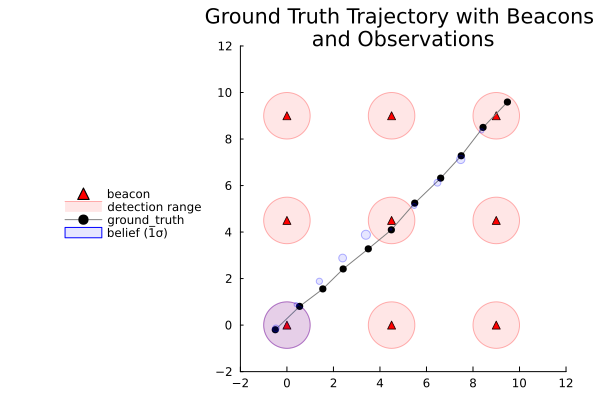

In [15]:
beliefs = Vector{FullNormal}(undef, T+1)
beliefs[1] = b
for t in 1:T
    zrel = τ_obs_beacons[t, :]
    beacon_index= beacon_indexes[t]
    z = (obs=zrel, beacon_index=beacon_index)

    if isnan(beacon_index)
        beliefs[t+1] = PropagateBelief(𝒫, beliefs[t], ai)
    else
        beliefs[t+1] = PosteriorBeliefRangedBeacons(𝒫, beliefs[t], ai, z)
    end
end


# -------------- PLOTTING --------------


# plot ground truth trajectory with beacons and observations:
# Plot beacons first (in the back)
pl_beacons = scatter(beacons[:,1], beacons[:,2], 
                     label="beacon", 
                     markershape=:utriangle, 
                     markersize=4,
                     markercolor=:red,
                     title="Ground Truth Trajectory with Beacons \nand Observations",
                     grid=false,
                     aspect_ratio=:equal,
                     xlims=(-2, 12),
                     ylims=(-2, 12),
                     legend=:outerleft,
                     background_color_legend=nothing,
                     foreground_color_legend=nothing)

# Add detection radius circles around each beacon
θ = range(0, 2π, length=100)
for i in 1:size(beacons, 1)
    x_circle = beacons[i, 1] .+ 𝒫.d * cos.(θ)
    y_circle = beacons[i, 2] .+ 𝒫.d * sin.(θ)
    plot!(pl_beacons, x_circle, y_circle, 
          fillrange=beacons[i, 2],
          fillalpha=0.1, 
          fillcolor=:red,
          linecolor=:red,
          linealpha=0.3,
          linewidth=1,
          label=i==1 ? "detection range" : "")
end

# Plot ground truth trajectory on top
plot!(pl_beacons, τ[:,1], τ[:,2], 
      label="ground_truth", 
      markershape=:circle, 
      markercolor=:black,
      linecolor=:gray, 
      linestyle=:solid)


# plot beliefs:
for t in 1:T+1
    bt = beliefs[t]
    covellipse!(pl_beacons, mean(bt), cov(bt), 
                n_std=1, 
                linecolor=:blue, 
                fillalpha=0.1, 
                fillcolor=:blue,
                label=t==1 ? "belief (1σ)" : "")
end

display(pl_beacons)

# (f-5) non-ranged observations

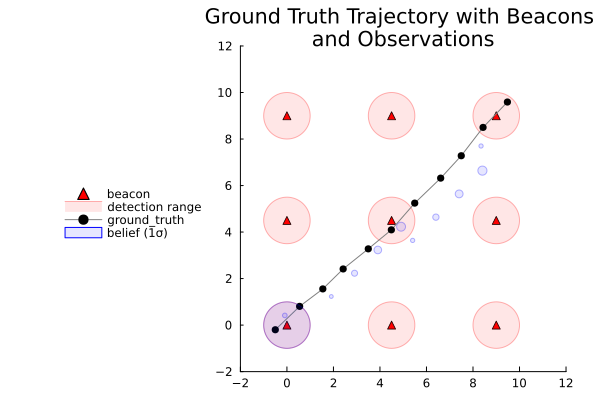

In [ ]:
# generate relative observations trajectory
τ_non_ranged_obs_beacons = []
non_ranged_beacon_indexes = []
for i in 1:T+1
    obs = GenerateObservationFromBeacons(𝒫, τ[i,:])

    if obs != nothing
        push!(τ_non_ranged_obs_beacons, obs[1])
        push!(non_ranged_beacon_indexes, obs[2])
    else
        push!(τ_non_ranged_obs_beacons, [NaN, NaN])  # or some other placeholder for no observation
        push!(non_ranged_beacon_indexes, NaN)
    end
end
τ_non_ranged_obs_beacons = hcat(τ_non_ranged_obs_beacons...)'  # convert to matrix form



non_ranged_beliefs = Vector{FullNormal}(undef, T+1)
non_ranged_beliefs[1] = b
for t in 1:T
    zrel = τ_non_ranged_obs_beacons[t, :]
    beacon_index= non_ranged_beacon_indexes[t]
    z = (obs=zrel, beacon_index=beacon_index)

    if isnan(beacon_index)
        non_ranged_beliefs[t+1] = PropagateBelief(𝒫, non_ranged_beliefs[t], ai)
    else
        non_ranged_beliefs[t+1] = PosteriorBeliefBeacons(𝒫, non_ranged_beliefs[t], ai, z)
    end
end


# -------------- PLOTTING --------------


# plot ground truth trajectory with beacons and observations:
# Plot beacons first (in the back)
pl_beacons = scatter(beacons[:,1], beacons[:,2], 
                     label="beacon", 
                     markershape=:utriangle, 
                     markersize=4,
                     markercolor=:red,
                     title="Ground Truth Trajectory with Beacons \nand Observations",
                     grid=false,
                     aspect_ratio=:equal,
                     xlims=(-2, 12),
                     ylims=(-2, 12),
                     legend=:outerleft,
                     background_color_legend=nothing,
                     foreground_color_legend=nothing)

# Add detection radius circles around each beacon
θ = range(0, 2π, length=100)
for i in 1:size(beacons, 1)
    x_circle = beacons[i, 1] .+ 𝒫.d * cos.(θ)
    y_circle = beacons[i, 2] .+ 𝒫.d * sin.(θ)
    plot!(pl_beacons, x_circle, y_circle, 
          fillrange=beacons[i, 2],
          fillalpha=0.1, 
          fillcolor=:red,
          linecolor=:red,
          linealpha=0.3,
          linewidth=1,
          label=i==1 ? "detection range" : "")
end

# Plot ground truth trajectory on top
plot!(pl_beacons, τ[:,1], τ[:,2], 
      label="ground_truth", 
      markershape=:circle, 
      markercolor=:black,
      linecolor=:gray, 
      linestyle=:solid)


# plot beliefs:
for t in 1:T+1
    bt = non_ranged_beliefs[t]
    covellipse!(pl_beacons, mean(bt), cov(bt), 
                n_std=1, 
                linecolor=:blue, 
                fillalpha=0.1, 
                fillcolor=:blue,
                label=t==1 ? "belief (1σ)" : "")
end

display(pl_beacons)

# (g) localization estimation errors versus time

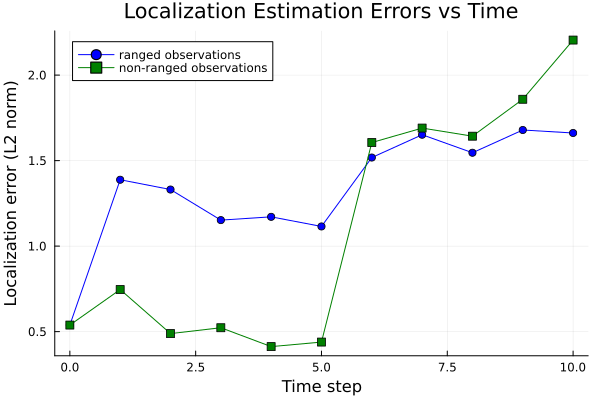

"/Users/jonathansomer/repos/apuu-hw2/plots/hw3/3g_localization_errors_318803129.png"

In [20]:
ranged_errors = [norm(beliefs[t].μ - τ[t, :]) for t in 1:T+1]
non_ranged_errors = [norm(non_ranged_beliefs[t].μ - τ[t, :]) for t in 1:T+1]

# plot both against time:
pl_errors = plot(0:T, ranged_errors, 
                 label="ranged observations", 
                 linecolor=:blue,
                 markershape=:circle,
                 markercolor=:blue,
                 xlabel="Time step",
                 ylabel="Localization error (L2 norm)",
                 title="Localization Estimation Errors vs Time",
                 legend=:topleft,
                 grid=true)

plot!(pl_errors, 0:T, non_ranged_errors, 
      label="non-ranged observations", 
      linecolor=:green,
      markershape=:square,
      markercolor=:green)

display(pl_errors)
savefig(pl_errors, joinpath(HW3_PLOTS, "3g_localization_errors_$ID.png"))

# (h) 

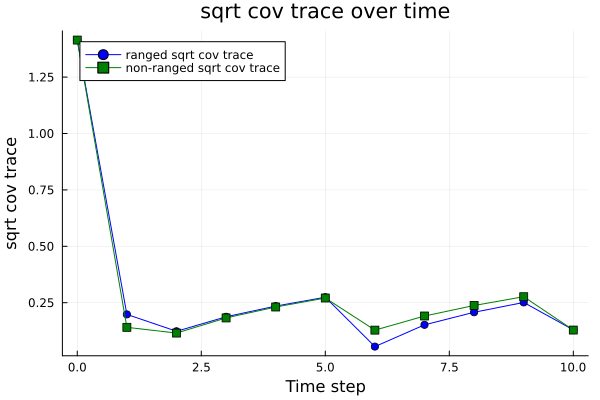

"/Users/jonathansomer/repos/apuu-hw2/plots/hw3/3h_cov_trace_318803129.png"

In [18]:
ranged_cov_trace = [sqrt(tr(beliefs[t].Σ)) for t in 1:T+1]
non_ranged_cov_trace = [sqrt(tr(non_ranged_beliefs[t].Σ)) for t in 1:T+1]

# plot both against time:
pl_errors = plot(0:T, ranged_cov_trace, 
                 label="ranged sqrt cov trace", 
                 linecolor=:blue,
                 markershape=:circle,
                 markercolor=:blue,
                 xlabel="Time step",
                 ylabel="sqrt cov trace",
                 title="sqrt cov trace over time",
                 legend=:topleft,
                 grid=true)

plot!(pl_errors, 0:T, non_ranged_cov_trace, 
      label="non-ranged sqrt cov trace", 
      linecolor=:green,
      markershape=:square,
      markercolor=:green)

display(pl_errors)
savefig(pl_errors, joinpath(HW3_PLOTS, "3h_cov_trace_$ID.png"))

# TODO - analyze results

# 2 - Planning

## 2a

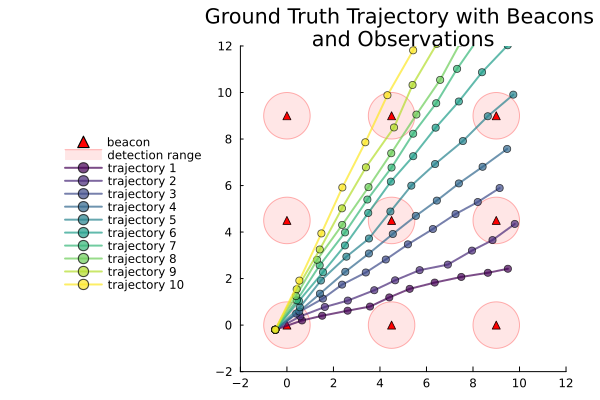

In [33]:
M = 10

function aij(j)
    return [1.0, 1.0 * 2*j/M]
end

taus = []

for j in 1:M
    τ = [X0] # trajectory
    for i in 1:T
        push!(τ, SampleMotionModel(𝒫, aij(j), τ[end]))
    end
    τ = hcat(τ...)'  # convert to matrix form
    push!(taus, τ)
end


# -------------- PLOTTING --------------


# plot ground truth trajectory with beacons and observations:
# Plot beacons first (in the back)
pl_beacons = scatter(beacons[:,1], beacons[:,2], 
                     label="beacon", 
                     markershape=:utriangle, 
                     markersize=4,
                     markercolor=:red,
                     title="Ground Truth Trajectory with Beacons \nand Observations",
                     grid=false,
                     aspect_ratio=:equal,
                     xlims=(-2, 12),
                     ylims=(-2, 12),
                     legend=:outerleft,
                     background_color_legend=nothing,
                     foreground_color_legend=nothing)

# Add detection radius circles around each beacon
θ = range(0, 2π, length=100)
for i in 1:size(beacons, 1)
    x_circle = beacons[i, 1] .+ 𝒫.d * cos.(θ)
    y_circle = beacons[i, 2] .+ 𝒫.d * sin.(θ)
    plot!(pl_beacons, x_circle, y_circle, 
          fillrange=beacons[i, 2],
          fillalpha=0.1, 
          fillcolor=:red,
          linecolor=:red,
          linealpha=0.3,
          linewidth=1,
          label=i==1 ? "detection range" : "")
end

# Color gradient from blue to green
colors = cgrad(:viridis, M, categorical=true)

for j in 1:M
    τ = taus[j]
    plot!(pl_beacons, τ[:,1], τ[:,2], 
          label="trajectory $j", 
          markershape=:circle, 
          markercolor=colors[j],
          linecolor=colors[j], 
          linestyle=:solid,
          linewidth=2,
          markeralpha=0.7,
          linealpha=0.7)
end


display(pl_beacons)

# 2b - Planning

Processing trajectory 1
  Time step 1: observed beacon index 1
  Time step 2: observed beacon index 1
Processing trajectory 2
  Time step 1: observed beacon index 1
  Time step 2: observed beacon index 1
  Time step 10: observed beacon index 6
  Time step 11: observed beacon index 6
Processing trajectory 3
  Time step 1: observed beacon index 1
  Time step 2: observed beacon index 1
Processing trajectory 4
  Time step 1: observed beacon index 1
  Time step 2: observed beacon index 1
  Time step 6: observed beacon index 5
Processing trajectory 5
  Time step 1: observed beacon index 1
  Time step 2: observed beacon index 1
  Time step 6: observed beacon index 5
  Time step 10: observed beacon index 9
Processing trajectory 6
  Time step 1: observed beacon index 1
Processing trajectory 7
  Time step 1: observed beacon index 1
Processing trajectory 8
  Time step 1: observed beacon index 1
Processing trajectory 9
  Time step 1: observed beacon index 1
  Time step 6: observed beacon index 8
P

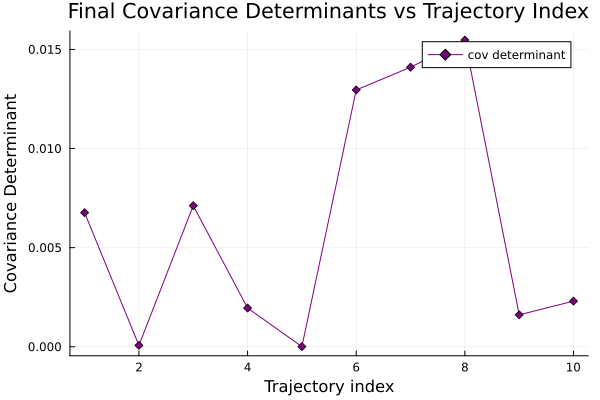

In [35]:
final_covs = []

for j in 1:M

    println("Processing trajectory $j")

    τ = taus[j]

    # generate observations
    τ_obs_beacons = []
    beacon_indexes = []
    for i in 1:T+1
        obs = GenerateRangedObservationFromBeacons(𝒫, τ[i,:])
        if obs != nothing
            push!(τ_obs_beacons, obs[1])
            push!(beacon_indexes, obs[2])
            println("  Time step $i: observed beacon index $(obs[2])")
        else
            push!(τ_obs_beacons, [NaN, NaN])  # or some other placeholder for no observation
            push!(beacon_indexes, NaN)
        end
    end
    τ_obs_beacons = hcat(τ_obs_beacons...)'  # convert to matrix form


    # compute posterior beliefs
    beliefs = Vector{FullNormal}(undef, T+1)
    beliefs[1] = b
    for t in 1:T
        zrel = τ_obs_beacons[t, :]
        beacon_index= beacon_indexes[t]
        z = (obs=zrel, beacon_index=beacon_index)

        if isnan(beacon_index)
            beliefs[t+1] = PropagateBelief(𝒫, beliefs[t], aij(j))
        else
            beliefs[t+1] = PosteriorBeliefRangedBeacons(𝒫, beliefs[t], aij(j), z)
        end
    end

    push!(final_covs, beliefs[end].Σ)

end


cov_determinants = [det(Σ) for Σ in final_covs]

# plot cov determinants versus trajectory index
pl_cov_det = plot(1:M, cov_determinants,
                  label="cov determinant",
                  linecolor=:purple,
                  markershape=:diamond,
                  markercolor=:purple,
                  xlabel="Trajectory index",
                  ylabel="Covariance Determinant",
                  title="Final Covariance Determinants vs Trajectory Index",
                  legend=:topright,
                  grid=true)

# Explanation:

Trajectory 5 passes through 3 beacons and finishes close to one. This reduces uncertainty significantly at multiple points in time.

Trajectory 2 passes through 2, but the number of times it passes near beacons is similar to trajectory 5 - 4 steps.